# Data analysis and propagation 

In [1]:
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import AutoMinorLocator
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import plotly.graph_objects as go


import os 
import pandas as pd
import scipy as sc 
import scipy.optimize as op
import ipywidgets  as widgets
from IPython.display import display
plt.style.use('default')
%matplotlib ipympl
%matplotlib widget



Loading the Excel file 
(.xlsx)

In [ ]:
file_path = ""
df = pd.read_excel(file_path)
print(df)

         1  0.288675    0  0.1
0        2  0.288675  0.0  0.0
1        3  0.288675  0.0  0.0
2        4  0.288675  0.0  0.0
3        5  0.288675  0.0  0.0
4        6  0.288675  0.0  0.0
...    ...       ...  ...  ...
8186  8188  0.288675  0.0  0.0
8187  8189  0.288675  0.0  0.0
8188  8190  0.288675  0.0  0.0
8189  8191  0.288675  0.0  0.0
8190  8192  0.288675  0.2  0.2

[8191 rows x 4 columns]


In [3]:
x = np.array(df.iloc[: ,0])
xerr = np.array(df.iloc[: ,1])
y = np.array(df.iloc[: ,2])
yerr = np.array(df.iloc[: ,3])

## plot data

/var/folders/s0/qcmc3cxj20155q3fyzb74s0c0000gn/T/ipykernel_91997/2611951714.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 10)


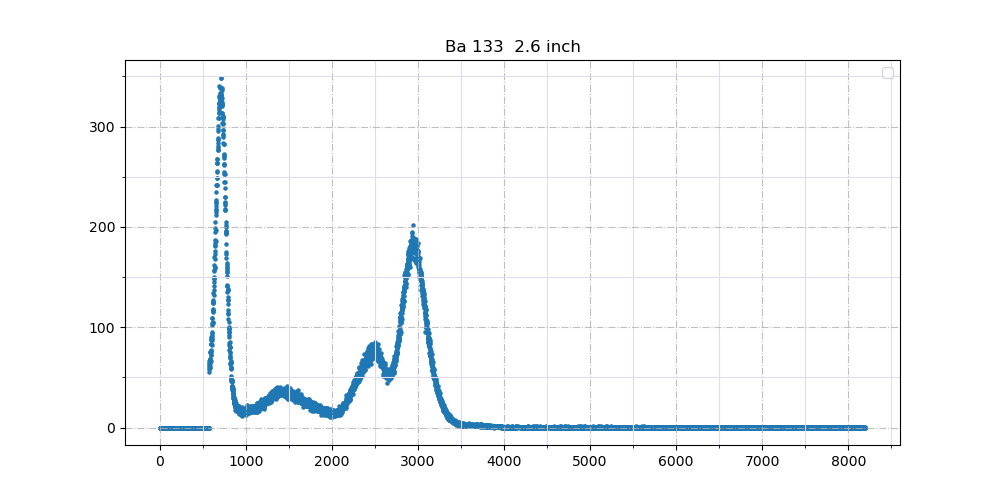

In [4]:


x = np.array(df.iloc[: ,0])
xerr = np.array(df.iloc[: ,1])
y = np.array(df.iloc[: ,2])
yerr = np.array(df.iloc[: ,3])

plt.figure( figsize =(10,5))
#plt.errorbar(x,y,xerr= xerr, yerr=yerr,label ="Data points", ecolor='gray', markersize=10)
plt.scatter(x,y, s= 5)
plt.ticklabel_format(style='plain', useOffset=False)

plt.gca().xaxis.set_major_locator(MultipleLocator(1000))
plt.gca().yaxis.set_major_locator(MultipleLocator(100))

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))

title = Path(file_path).stem   # filename without ".xlsx"
plt.title(title)
plt.grid(True, linestyle='-.', alpha=0.8, )
plt.grid(True, 'minor', color='#ddddee') 
plt.legend(fontsize = 10)
plt.show()

## preparing data for fitting

### pont averaging

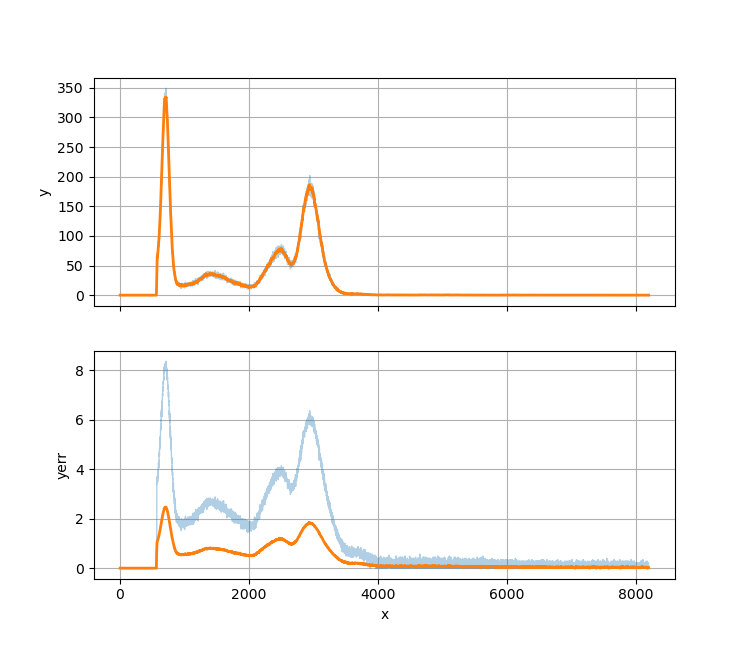

In [5]:


# ----------------------------
# Helpers: smoothing + error propagation
# ----------------------------
def moving_average(y, w):
    k = np.ones(w, dtype=float) / w
    return np.convolve(y, k, mode="same")

def kernel_moving_average(w):
    return np.ones(w, dtype=float) / w

try:
    from scipy.signal import savgol_filter
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False

def savgol(y, w, poly=3):
    # window length must be odd and > poly
    if w % 2 == 0:
        w += 1
    if w <= poly:
        w = poly + 2 if (poly + 2) % 2 == 1 else poly + 3
    return savgol_filter(y, window_length=w, polyorder=poly, mode="interp")

def propagate_yerr_linear_filter(yerr, k):
    """
    If y_smooth = k * y (linear convolution), and y errors are independent:
    var(y_smooth[i]) = sum_j (k_j^2 * var(y[i-j]))
    So yerr_smooth = sqrt( conv(yerr^2, k^2) )
    """
    yerr2 = np.asarray(yerr, dtype=float) ** 2
    k2 = np.asarray(k, dtype=float) ** 2
    return np.sqrt(np.convolve(yerr2, k2, mode="same"))

def to_odd(w):
    return int(w) if int(w) % 2 == 1 else int(w) + 1

# ----------------------------
# Inputs
# ----------------------------
x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
xerr = np.asarray(xerr, dtype=float)
yerr = np.asarray(yerr, dtype=float)

n = len(y)
assert len(x) == n and len(xerr) == n and len(yerr) == n, "x,y,xerr,yerr must be same length"

# ----------------------------
# Precompute
# ----------------------------
max_w = min(501, n if n % 2 == 1 else n - 1)  # keep reasonable and odd
min_w = 3
step = 2  # odd windows only
window_sizes = np.arange(min_w, max_w + 1, step, dtype=int)

precomp_y = {}
precomp_yerr = {}

# Moving average (we also precompute propagated yerr exactly)
precomp_y[("Moving average", None)] = {}
precomp_yerr[("Moving average", None)] = {}
for w in window_sizes:
    k = kernel_moving_average(w)
    precomp_y[("Moving average", None)][w] = moving_average(y, w)
    precomp_yerr[("Moving average", None)][w] = propagate_yerr_linear_filter(yerr, k)

# Savitzky-Golay (y precompute; yerr handling selectable)
# Exact propagation for SavGol is possible but needs filter coefficients per point;
# default here: keep yerr unchanged OR do local RMS (approx).
if HAVE_SCIPY:
    for poly in (2, 3, 4, 5):
        key = ("Savitzky-Golay", poly)
        precomp_y[key] = {}
        precomp_yerr[key] = {}
        for w in window_sizes:
            ww = to_odd(w)
            precomp_y[key][w] = savgol(y, ww, poly=poly)
            # placeholder; will be set later depending on yerr mode selection
            precomp_yerr[key][w] = yerr.copy()

# ----------------------------
# Widgets
# ----------------------------
method_options = [("Moving average", ("Moving average", None))]
if HAVE_SCIPY:
    for poly in (2, 3, 4, 5):
        method_options.append((f"Savitzky-Golay (poly={poly})", ("Savitzky-Golay", poly)))

method_dd = widgets.Dropdown(
    options=method_options,
    value=("Moving average", None),
    description="Method:",
    layout=widgets.Layout(width="320px"),
)

w_slider = widgets.IntSlider(
    value=11 if 11 in window_sizes else int(window_sizes[0]),
    min=int(window_sizes.min()),
    max=int(window_sizes.max()),
    step=int(step),
    description="Window:",
    continuous_update=True,
    layout=widgets.Layout(width="520px"),
)

# yerr treatment
# - "Propagate (linear)" is exact for Moving average (and any kernel we explicitly use)
# - "Keep as-is" is safest for SavGol
# - "Scale by sqrt(N)" is a common rough heuristic (not exact); offered as option
yerr_mode = widgets.Dropdown(
    options=[
        ("Propagate (linear filter)", "propagate"),
        ("Keep yerr unchanged", "keep"),
        ("Scale by 1/sqrt(window)", "scale_sqrt"),
    ],
    value="propagate",
    description="yerr:",
    layout=widgets.Layout(width="320px"),
)

show_raw = widgets.Checkbox(value=True, description="Show raw")
show_smooth = widgets.Checkbox(value=True, description="Show smooth")
alpha_raw = widgets.FloatSlider(
    value=0.35, min=0.0, max=1.0, step=0.05,
    description="Raw α:",
    continuous_update=True,
    layout=widgets.Layout(width="320px"),
)

export_btn = widgets.Button(
    description="Export smoothing → overwrite x,y,xerr,yerr",
    button_style="success",
    layout=widgets.Layout(width="420px"),
)
status = widgets.HTML(value="")

# ----------------------------
# Plot (main + yerr view)
# ----------------------------
fig, (ax, axe) = plt.subplots(2, 1, sharex=True, figsize=(7.5, 6.5))
raw_line, = ax.plot(x, y, lw=1)
smooth_line, = ax.plot(x, precomp_y[method_dd.value][w_slider.value], lw=2)

ax.set_ylabel("y")
ax.grid(True)

raw_err_line, = axe.plot(x, yerr, lw=1)
smooth_err_line, = axe.plot(x, precomp_yerr[method_dd.value][w_slider.value], lw=2)

axe.set_xlabel("x")
axe.set_ylabel("yerr")
axe.grid(True)

# ----------------------------
# State + update logic
# ----------------------------
def get_current_smoothed():
    key = method_dd.value
    w = int(w_slider.value)

    # snap to nearest valid precomputed window
    if w not in precomp_y[key]:
        w = int(window_sizes[np.argmin(np.abs(window_sizes - w))])
        w_slider.value = w

    y_s = precomp_y[key][w]

    # choose yerr handling
    if yerr_mode.value == "keep":
        yerr_s = yerr.copy()
    elif yerr_mode.value == "scale_sqrt":
        yerr_s = yerr / np.sqrt(w)
    else:
        # propagate if available; exact for Moving average in our precompute
        # for SavGol we fall back to "keep" unless you extend with exact coeffs
        if key[0] == "Moving average":
            yerr_s = precomp_yerr[key][w]
        else:
            yerr_s = yerr.copy()

    return y_s, yerr_s

def update(*_):
    y_s, yerr_s = get_current_smoothed()

    raw_line.set_visible(show_raw.value)
    smooth_line.set_visible(show_smooth.value)

    raw_err_line.set_visible(show_raw.value)
    smooth_err_line.set_visible(show_smooth.value)

    raw_line.set_alpha(alpha_raw.value)
    raw_err_line.set_alpha(alpha_raw.value)

    smooth_line.set_ydata(y_s)
    smooth_err_line.set_ydata(yerr_s)

    ax.relim(); ax.autoscale_view()
    axe.relim(); axe.autoscale_view()
    fig.canvas.draw_idle()

for wid in (method_dd, w_slider, yerr_mode, show_raw, show_smooth, alpha_raw):
    wid.observe(update, names="value")

# Disable "propagate" option when not meaningful
def enforce_yerr_mode(*_):
    key = method_dd.value
    if key[0] != "Moving average" and yerr_mode.value == "propagate":
        yerr_mode.value = "keep"
enforce_yerr_mode()
method_dd.observe(enforce_yerr_mode, names="value")

update()

# ----------------------------
# Export callback
# ----------------------------
def on_export(_):
    global x, y, xerr, yerr
    y_s, yerr_s = get_current_smoothed()

    # overwrite in-place variables
    # x, xerr unchanged (smoothing doesn't change x-axis positions)
    y = y_s.copy()
    yerr = yerr_s.copy()

    status.value = (
        "<b>Exported.</b> Overwrote <code>y</code> and <code>yerr</code> in the notebook.<br>"
        f"Method: <code>{method_dd.label}</code>, window: <code>{int(w_slider.value)}</code>, "
        f"yerr mode: <code>{yerr_mode.label}</code>."
    )

export_btn.on_click(on_export)

controls = widgets.VBox([
    widgets.HBox([method_dd, yerr_mode]),
    w_slider,
    widgets.HBox([show_raw, show_smooth, alpha_raw]),
    widgets.HBox([export_btn]),
    status
])

display(controls)
plt.show()

### defining range of $x$

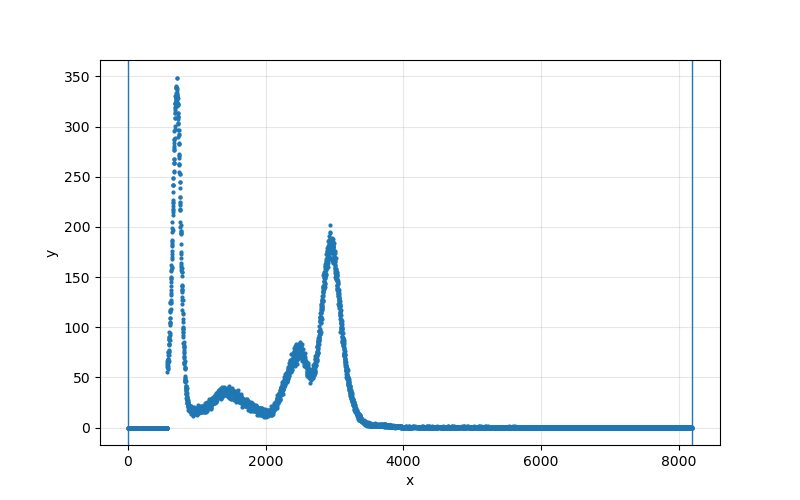

In [6]:
n = len(x)
assert len(y) == n and len(xerr) == n and len(yerr) == n, "x,y,xerr,yerr must be same length"

xmin0 = float(np.nanmin(x))
xmax0 = float(np.nanmax(x))

# If x is not strictly increasing, we still can mask by range, but slider feels nicer if sorted.
# We'll keep original order; mask is based on x values.
range_slider = widgets.FloatRangeSlider(
    value=[xmin0, xmax0],
    min=xmin0,
    max=xmax0,
    step=(xmax0 - xmin0) / 1000 if xmax0 > xmin0 else 1.0,
    description="x range:",
    continuous_update=True,
    readout=True,
    layout=widgets.Layout(width="650px"),
)

export_btn = widgets.Button(
    description="Export cut → overwrite x,y,xerr,yerr",
    button_style="success",
    layout=widgets.Layout(width="420px"),
)
status = widgets.HTML(value="")

fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot(x, y, ".", ms=4)

# optional: show selection bounds
vleft = ax.axvline(range_slider.value[0], lw=1)
vright = ax.axvline(range_slider.value[1], lw=1)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)

def current_mask():
    a, b = map(float, range_slider.value)
    lo, hi = (a, b) if a <= b else (b, a)
    m = (x >= lo) & (x <= hi)
    return lo, hi, m

def update(*_):
    lo, hi, m = current_mask()
    line.set_data(x[m], y[m])
    vleft.set_xdata([lo, lo])
    vright.set_xdata([hi, hi])
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

def on_export(_):
    global x, y, xerr, yerr
    lo, hi, m = current_mask()

    # overwrite with cut data
    x = x[m].copy()
    y = y[m].copy()
    xerr = xerr[m].copy()
    yerr = yerr[m].copy()

    status.value = (
        f"<b>Exported.</b> Overwrote arrays with x in "
        f"<code>[{lo:.6g}, {hi:.6g}]</code>. Kept <code>{len(x)}</code> points."
    )

    # refresh slider + plot for new data extent
    new_min, new_max = float(np.nanmin(x)), float(np.nanmax(x))
    range_slider.min = new_min
    range_slider.max = new_max
    range_slider.value = (new_min, new_max)
    update()

range_slider.observe(update, names="value")
export_btn.on_click(on_export)

update()

display(widgets.VBox([range_slider, export_btn, status]))
plt.show()

### visualize final data

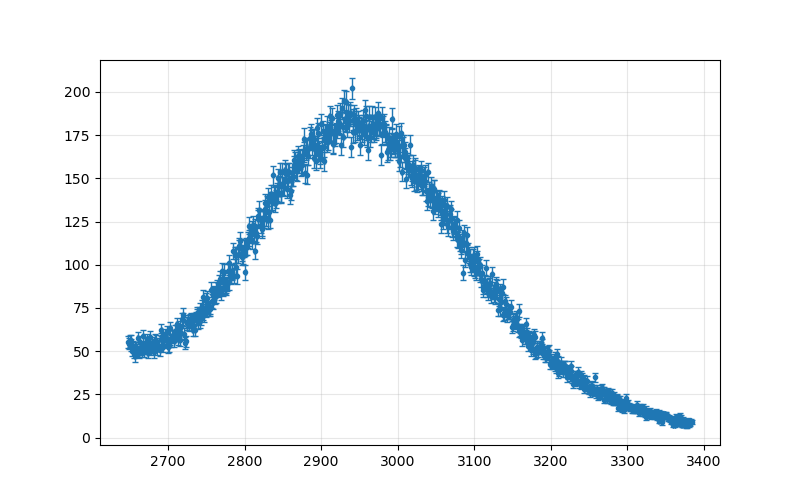

In [7]:
x = np.asarray(x, float)
y = np.asarray(y, float)
xerr = np.asarray(xerr, float)
yerr = np.asarray(yerr, float)

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    x, y,
    xerr=xerr, yerr=yerr,
    fmt=".",            # marker style
    linestyle="none",   # no connecting line
    capsize=2,          # little caps on error bars
    elinewidth=1,
)


ax.grid(True, alpha=0.3)
plt.show()

## Fitting functions

In [ ]:
def linear(x, a,b): 
    y_fit = x*a + b
    return np.array(y_fit) 
def gaussian(x, c, amp, mu, sig):
    # your exact formula (note: you used A[3] as a variance-like term)
    return c + amp * np.exp(-0.5*((x - mu)**2 / sig**2))

def gaussian_inverseNoise(x, c, amp, mu1, sig, a, mu2):
    return c + amp * np.exp(-0.5*((x - mu1)**2 / sig**2)) + 1/a*(x - mu2)

def gaussian_expoNoise(x, c, amp, mu1, sig, a, mu2):
    return c + amp * np.exp(-0.5*((x - mu1)**2 / sig**2)) + np.exp(a*(x - mu2))

## Set initial guess for the parameters  

In [ ]:

func = gaussian
P = [18, 340, 700, 60]

## $\chi^2_{red}$ calculation

In [ ]:
def chi2_red(x, y, yerr, y_fit):
    N = len(x)
    res = y - y_fit
    chi2 = np.sum((res/yerr)**2)      
    nu = N   
    chi2_red = chi2 / nu
    return(chi2_red)

# Fitting algorythm

## scipy.optimize.curve_fit

In [ ]:
for i in range(len(yerr)):
    if yerr[i] == 0:
        yerr[i] = 0.01  # or some small value to avoid division by zero

In [ ]:

popt, pcov = op.curve_fit(func, x, y, P, sigma= yerr, maxfev = 200000)

In [ ]:
print("the optimal parameters are:", popt)
diag = np.diagonal(pcov)
print("The error matrix is:")
print(diag)

y_fit = func(x, *popt)
print("The chi2_red value is :", chi2_red(x, y, yerr, y_fit))


# fitting plot

In [ ]:
from matplotlib.pyplot import ylim


plt.figure( figsize =(10,5))
plt.plot(x , y_fit, color = 'r', label = r"$0.486 + 2.69\,\exp\!\left[-\frac{(x - 21.754)^2}{2\cdot (0.514)}\right]$")
plt.scatter(x,y, marker="o", s = 10)
plt.ylabel("Counts/h", fontsize=12)
plt.xlabel("Energy (keV)", fontsize=12)

plt.gca().xaxis.set_major_locator(MultipleLocator(100))
plt.gca().yaxis.set_major_locator(MultipleLocator(100))

plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))

title = Path(file_path).stem   # filename without ".xlsx"
plt.title(title + " (peak 1)")
plt.grid()
plt.grid(True, 'minor', color='#ddddee', linestyle='-.', alpha=0.8) 
plt.show()